<a href="https://colab.research.google.com/github/Priya4740/machine-learning/blob/main/RANDOM_FOREST_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libararies


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(confusion_matrix,ConfusionMatrixDisplay,accuracy_score)

In [ ]:
iris=datasets.load_iris()
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
print("Target Names :")
print(iris.target_names)
print("Feature Names :")
print(iris.feature_names)
print("\nFirst Five Records")
print(iris.data[:5])
print("\nTarget lables")
print(iris.target[:10])

Target Names :
['setosa' 'versicolor' 'virginica']
Feature Names :
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First Five Records
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Target lables
[0 0 0 0 0 0 0 0 0 0]


#create a dataframe


In [ ]:
data=pd.DataFrame({
    "sepal length":iris.data[:,0],
    "sepal width":iris.data[:,1],
    "petal length":iris.data[:,2],
    "petal width":iris.data[:,3],
    "species":iris.target
})

In [ ]:
print("shape of dataset: ")
print(data.shape)
print("\nDataset information")
print(data.info())
print("\nStatistical summary")
print(data.describe())
print("\nMissing values")
print(data.isnull().sum())

shape of dataset: 
(150, 5)

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical summary
       sepal length  sepal width  petal length  petal width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      

In [ ]:
x=data[['sepal length','sepal width','petal length','petal width']]
y=data[['species']]
print("Features Shape :",x.shape)
print("Target Values :",y.shape)

Features Shape : (150, 4)
Target Values : (150, 1)


In [ ]:
x

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
print("Training Samples:",x_train.shape)
print("Testing Samples:",x_test.shape)

Training Samples: (105, 4)
Testing Samples: (45, 4)


In [ ]:
classifier=RandomForestClassifier(n_estimators=100,random_state=42)
classifier.fit(x_train,y_train)
print("Model Trained Successfully")


Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
y_pred=classifier.predict(x_test)
print("First 10 predictions")
print(y_pred[:10])

First 10 predictions
[1 0 2 1 1 0 1 2 1 1]


In [ ]:
comparsion=pd.DataFrame({'Actual':y_test['species'].values,'Predicted':y_pred})
comparsion.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


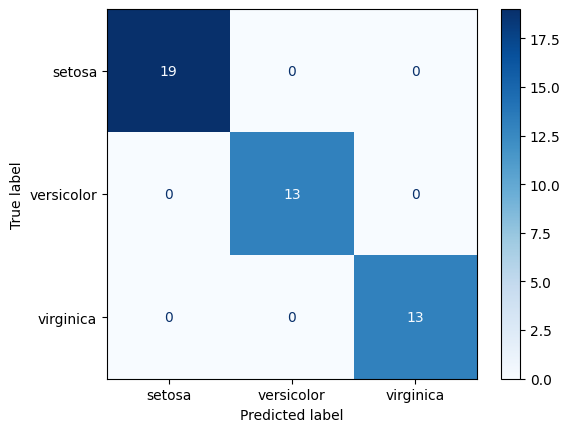

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
print(cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title=("Confusion matrix : ")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("Accuracy Percentage:",accuracy*100,"%")

Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [ ]:
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred, average='macro')
print("Precision:",precision)
print("Accuracy Percentage:",accuracy*100,"%")

Precision: 1.0
Accuracy Percentage: 100.0 %


In [ ]:
new_flower=[[3,4,5,1]]
prediction=classifier.predict(new_flower)
print("Predicted Class:",prediction)
print("Flower Species :",iris.target_names[prediction][0])

Predicted Class: [1]
Flower Species : versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
